In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
dataset_path = "dataset/dataset-sensitivity2-uf250-1065.csv"
df = pd.read_csv(dataset_path)

# drop columns where all values are 0
for col in df.columns:
    if df[col].nunique() == 1:
        df = df.drop(columns=[col])
print(df.columns)

Index(['file', 'option', 'Time (ms)', 'Replayed Propagation',
       'Skipped Propagation', 'Sync', 'Restart', 'Forward subsumption in set',
       'Conflict repair', 'Failed learning', 'Backtrack forced chunks',
       'Backtrack better chunks', 'Decisions', 'Conflicts', 'Propagation',
       'Implication', 'Unassignment', 'Remove propagation', 'Check invariants',
       'Update level', 'Time', 'Clause deleted', 'Clause set simplified',
       'Delete clause', 'Remove literal', 'Block'],
      dtype='object')


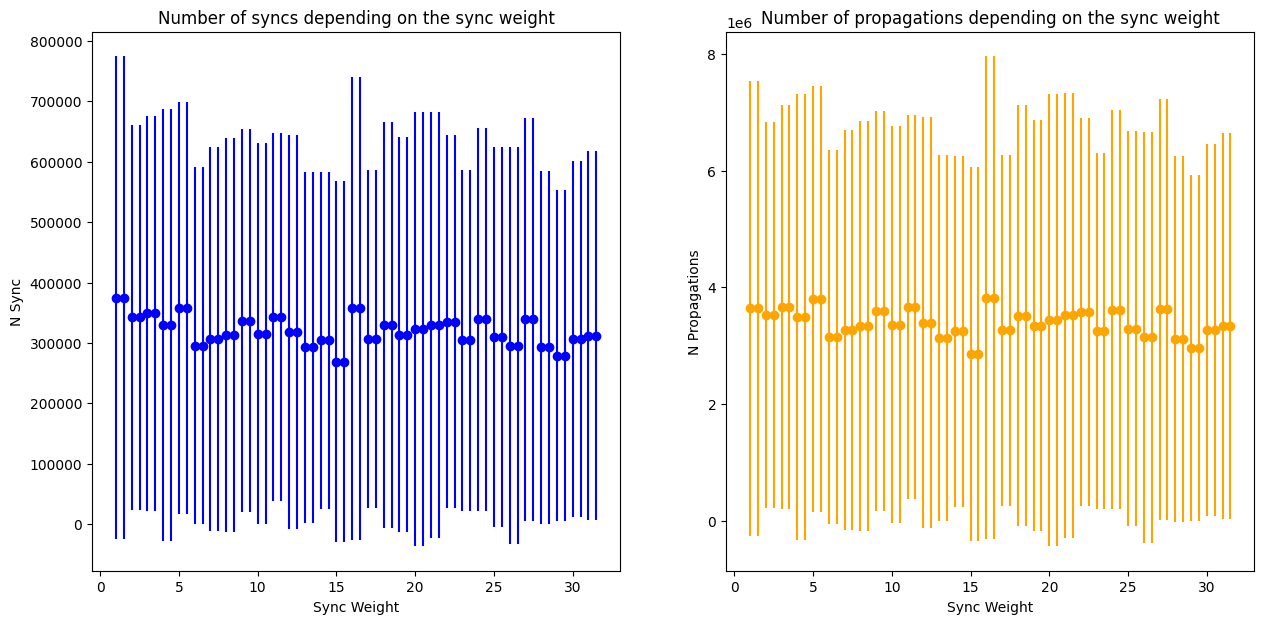

In [37]:
# Gather all sync-weight values from options
sync_weights = []
for opt in options:
    if "--sync-weight" in opt:
        try:
            sync_weights.append(float(opt.split()[-1]))
        except ValueError:
            pass
sync_weights = sorted(set(sync_weights))
separated_per_sync_weight = {opt: df[df['option'] == opt] for opt in options}
sync_avg = []
sync_std = []
propagation_avg = []
propagation_std = []
for weight in sync_weights:
    opt = f"-gb --sync-weight {int(weight)}" if f"-gb --sync-weight {int(weight)}" in separated_per_sync_weight else f"-gb --sync-weight {weight}"
    sync_avg.append(separated_per_sync_weight[opt]['Sync'].mean())
    sync_std.append(separated_per_sync_weight[opt]['Sync'].std())
    propagation_avg.append(separated_per_sync_weight[opt]['Propagation'].mean())
    propagation_std.append(separated_per_sync_weight[opt]['Propagation'].std())
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.errorbar(sync_weights, sync_avg, yerr=sync_std, fmt='o', color='blue', label='Sync')
plt.xlabel('Sync Weight')
plt.ylabel('N Sync')
plt.title('Number of syncs depending on the sync weight')
plt.subplot(1, 2, 2)
plt.errorbar(sync_weights, propagation_avg, yerr=propagation_std, fmt='o', color='orange', label='Propagation')
plt.xlabel('Sync Weight')
plt.ylabel('N Propagations')
plt.title('Number of propagations depending on the sync weight')
plt.show()

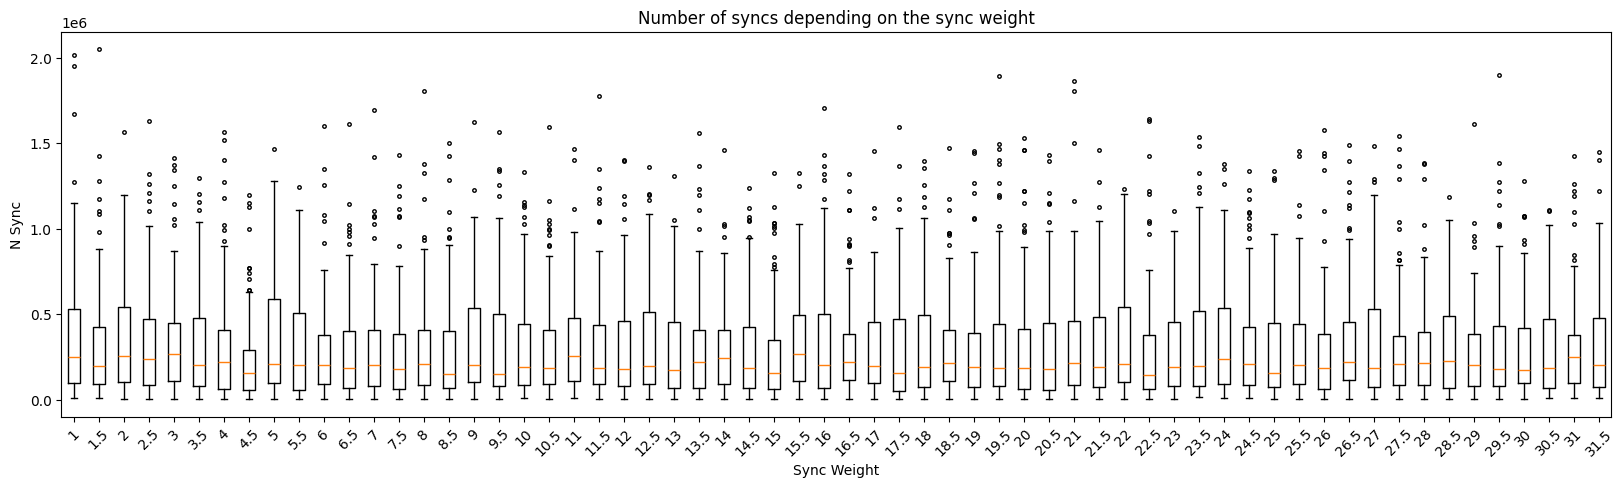

In [38]:
df_split = {}
for opt in options:
    if "--sync-weight" not in opt:
        continue
    weight = opt.split()[-1]
    df_split[weight] = df[df['option'] == opt]
    df_split[weight] = df_split[weight].reset_index(drop=True)

plt.figure(figsize=(20, 5))
# plt.subplot(1, 2, 1)
data_to_plot = [df_split[weight]['Sync'] for weight in sorted(df_split.keys(), key=lambda x: float(x))]
plt.boxplot(data_to_plot, showfliers=True, flierprops=dict(marker='.', color='red', markersize=5))
# set the x ticks to the option names
plt.xticks(range(1, len(data_to_plot) + 1), sorted(df_split.keys(), key=lambda x: float(x)), rotation=45)
plt.xlabel('Sync Weight')
plt.ylabel('N Sync')
plt.title('Number of syncs depending on the sync weight')
# plt.subplot(1, 2, 2)
# data_to_plot = [df_split[weight]['Propagation'] for weight in sorted(df_split.keys(), key=lambda x: float(x))]
# # set the outlier marker as a dot
# plt.boxplot(data_to_plot, showfliers=True, flierprops=dict(marker='.', color='red', markersize=5))
# # set the x ticks to the option names
# plt.xticks(range(1, len(data_to_plot) + 1), sorted(df_split.keys(), key=lambda x: float(x)), rotation=45)
# plt.xlabel('Sync Weight')
# plt.ylabel('N Propagations')
# plt.title('Number of propagations depending on the sync weight')
plt.show()
